Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


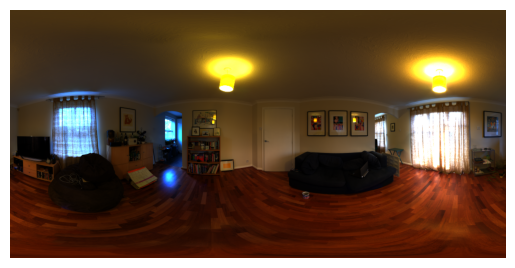

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


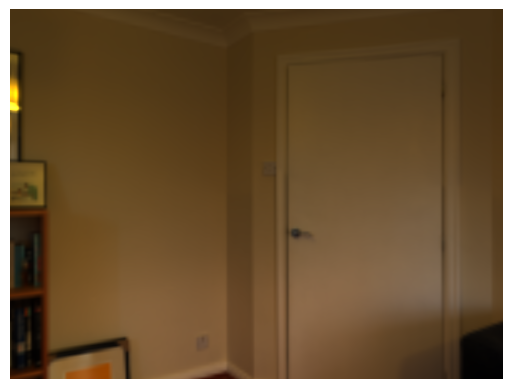

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


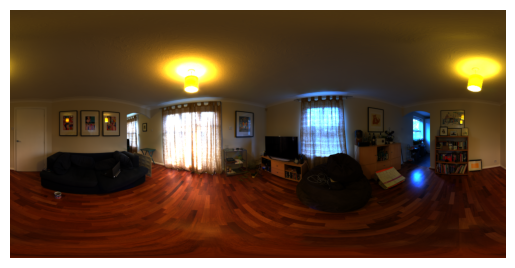

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


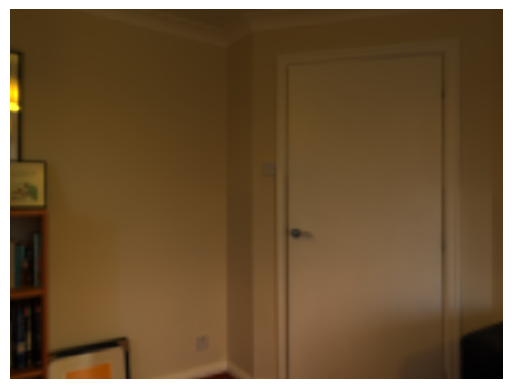

In [33]:
import numpy as np
import numpy as np
import torch as th
import json, os, glob
import imageio
import torch
import cv2
import multiprocessing as mp
import matplotlib.pyplot as plt
from PIL import Image
from envmap import EnvironmentMap, rotation_matrix
import math

def compute_horizontal_fov(sensor_width_mm, focal_length_mm, image_width_px):
    # Compute focal length in pixels
    focal_length_px = focal_length_mm * image_width_px / sensor_width_mm
    
    # Compute FoV in radians, then convert to degrees
    fov_rad = 2 * math.atan(image_width_px / (2 * focal_length_px))
    fov_deg = math.degrees(fov_rad)
    
    return fov_deg

os.environ["OPENCV_IO_ENABLE_OPENEXR"]="1"
def read_hdr(path):
    """Reads an HDR map from disk.

    Args:
        path (str): Path to the .hdr file.

    Returns:
        numpy.ndarray: Loaded (float) HDR map with RGB channels in order.
    """
    try:
        with open(path, 'rb') as h:
            buffer_ = np.frombuffer(h.read(), np.uint8)
        bgr = cv2.imdecode(buffer_, cv2.IMREAD_UNCHANGED)
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    except Exception as e:
        print(f"Error reading HDR file {path}: {e}")
        rgb = None
        return rgb
    rgb = torch.from_numpy(rgb)
    return rgb

def plot(e, dcm=None):
    plt.imshow(e.data)
    plt.axis('off')
    plt.show()

    sensor_width = 32         # mm
    focal_length = 35         # mm
    resolution_x = 256        # pixels

    fov = compute_horizontal_fov(sensor_width, focal_length, resolution_x)
    
    pose = np.load("/home/mint/Dev/DiFaReli/TPAMI_baseline_MajorRevision/Neural_Gaffer/demo/default_pose.npy")
    e_proj = e.project(vfov=fov, rotation_matrix=np.eye(3) if dcm is None else dcm) 
    plt.imshow(e_proj.data)
    plt.axis('off')
    plt.show()

# path = "/data/mint/DPM_Dataset/Dataset_For_Baseline/NeuralGaffer/lighting_for_inference/rotate_sh_axis=1_azimuth/064_hdrmaps_com_free_2K/HDR"
envir_map_path = "/home/mint/Dev/DiFaReli/TPAMI_baseline_MajorRevision/Neural_Gaffer/demo/environment_map_sample/064_hdrmaps_com_free_2K.exr"
hdr_rgb = read_hdr(envir_map_path)  # Read raw value in RGB order [0, some_large_value]

e = EnvironmentMap(hdr_rgb.cpu().numpy(), 'latlong')

axis = 'azimuth'
i = 180
rot_deg = i*np.pi/180
dcm = rotation_matrix(azimuth=rot_deg if axis == 'azimuth' else 0,
                    elevation=rot_deg if axis == 'elevation' else 0,
                    roll=rot_deg if axis == 'roll' else 0)
e_rot = e.copy().rotate(dcm)
plot(e)
plot(e_rot, dcm)
